In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('German_Credit_data (2).csv')
df

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


### DATA UNDERSTANDING

In [3]:
df.size

21000

In [4]:
df.shape

(1000, 21)

In [5]:
df.columns

Index(['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings',
       'employment_duration', 'installment_rate', 'personal_status_sex',
       'other_debtors', 'present_residence', 'property', 'age',
       'other_installment_plans', 'housing', 'number_credits', 'job',
       'people_liable', 'telephone', 'foreign_worker', 'credit_risk'],
      dtype='str')

In [6]:
df.dtypes

status                     int64
duration                   int64
credit_history             int64
purpose                    int64
amount                     int64
savings                    int64
employment_duration        int64
installment_rate           int64
personal_status_sex        int64
other_debtors              int64
present_residence          int64
property                   int64
age                        int64
other_installment_plans    int64
housing                    int64
number_credits             int64
job                        int64
people_liable              int64
telephone                  int64
foreign_worker             int64
credit_risk                int64
dtype: object

In [7]:
df.describe()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,...,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,1.145000,...,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.845000,1.404000,1.963000,0.700000
std,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,0.477706,...,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856,0.458487
min,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,1.000000,...,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,1.000000,...,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000
50%,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,1.000000,...,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000
75%,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,1.000000,...,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,1.000000
max,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,3.000000,...,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000,1.000000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   int64
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   int64
 3   purpose                  1000 non-null   int64
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   int64
 6   employment_duration      1000 non-null   int64
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   int64
 9   other_debtors            1000 non-null   int64
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   int64
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   int64
 14  housing                  1000 non-null   int64
 15  number_credits  

In [9]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

### Feature Encoding Description
The dataset is provided in encoded form. The meaning of encoded values for categorical variables is known and used for interpretation during EDA and modeling.
- #### status:
  * 1 = No checking account
  * 2 = Balance <0
  * 3 = Balance between 0 and 200
  * 4 = Balance above 200
- #### credit_history:
  * 0 = No previous credit / all paid on time
  * 1 = All credit paid on time
  * 2 = existing credits paid on time
  * 3 = Delay in past payments
  * 4 = Critival account
- #### purpose
  * 0 = Car (new)
  * 1 = Car (used)
  * 2 = Furniture / Equipment
  * 3 = Radio / Television
  * 4 = Domestic appliances
  * 5 = Repairs
  * 6 = Education
  * 7 = Vacation
  * 8 = Retraining
  * 9 = Business
  * 10 = Others
- #### savings
  * 1 = No savings
  * 2 = <100
  * 3 = 100-500
  * 4 = 500-1000
  * 5 = >=1000
- #### employment_duration
  * 1 = unemployed
  * 2 = <1 year
  * 3 = 1-4 years
  * 4 = 4-7 years
  * 5 = >=7 years
- #### installment_rate
  * 1 = Low burden
  * 2 = Moderate
  * 3 = High
  * 4 = Very High
- #### personal_status_sex
  * 1 = Male, divorced / separated
  * 2 = Female, divorced / sepearted / married
  * 3 = Male, single
  * 4 = Male, married / widowed
- #### other_debtors
  * 1 = None
  * 2 = Co-applicants
  * 3 = Gaurantors
- #### present_residence
  * 1 = <1 year
  * 2 = 1-4 years
  * 3 = 4-7 years
  * 4 = >=7 year
- #### property
  * 1 = Real estate
  * 2 = Life insurance
  * 3 = Car or other
  * 4 = No property
- #### other_installment_plans
  * 1 = Bank
  * 2 = Store
  * 3 = None
- #### housing
  * 1 = Rent
  * 2 = Own
  * 3 = Free
- #### job
  * 1 = Unemployed / unskilled
  * 2 = Unskilled
  * 3 = Skilled worker
  * 4 = Highly skilled
- #### people_liable
  * 1 = One person
  * 2 = Two or more
- #### telephone
  * 1 = No
  * 2 = Yes
- #### foreign_worker
  * 1 = Yes
  * 2 = No
- #### credit_risk
  * 1 = Good credit risk
  * 2 = Bad credit risk
  

### EDA

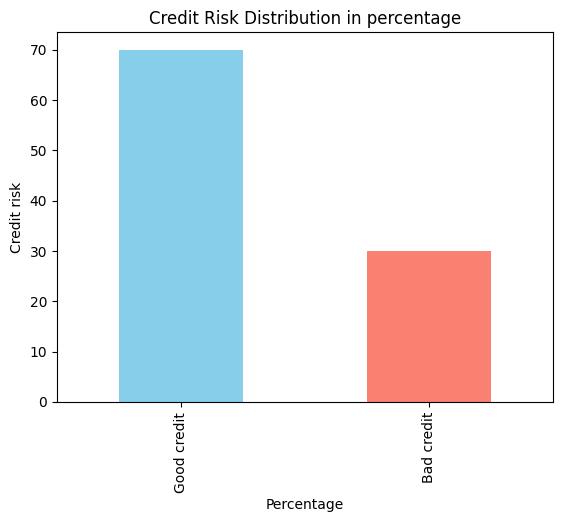

In [11]:
(df['credit_risk']
 .value_counts(normalize=True)
 .mul(100)
 .rename({1: 'Good credit',0: 'Bad credit'})
 .plot(kind='bar',color=['skyblue','salmon']))
plt.title('Credit Risk Distribution in percentage')
plt.xlabel('Percentage')
plt.ylabel('Credit risk')
plt.show()

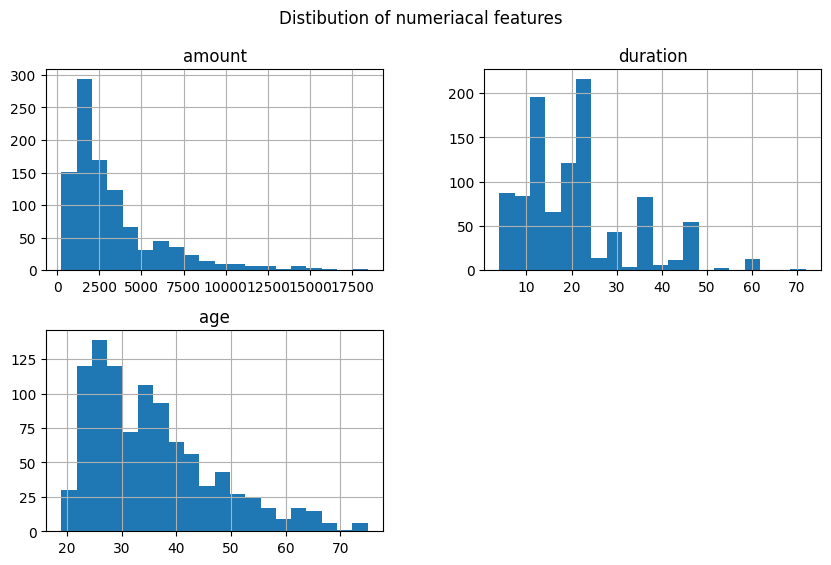

In [12]:
df[['amount','duration','age']].hist(bins=20,figsize=(10,6))
plt.suptitle('Distibution of numeriacal features')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11140\1986155624.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_risk',y='amount',data=df,palette={'skyblue','salmon'},order=[0,1])


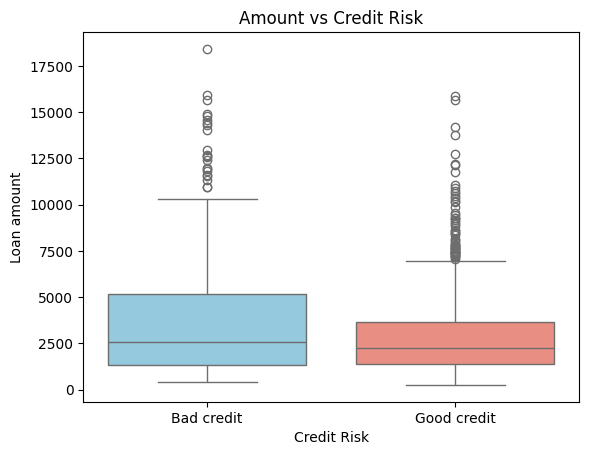

In [13]:
sns.boxplot(x='credit_risk',y='amount',data=df,palette={'skyblue','salmon'},order=[0,1])
plt.xticks([1,0],['Good credit','Bad credit'])
plt.xlabel('Credit Risk')
plt.ylabel('Loan amount')
plt.title('Amount vs Credit Risk')
plt.show()

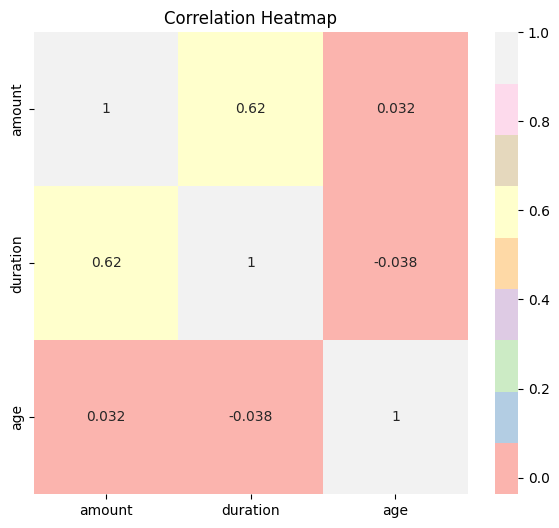

In [14]:
plt.figure(figsize=(7,6))
corr=df[['amount','duration','age']].corr()
sns.heatmap(corr,cmap='Pastel1',annot=True)
plt.title('Correlation Heatmap')
plt.show()

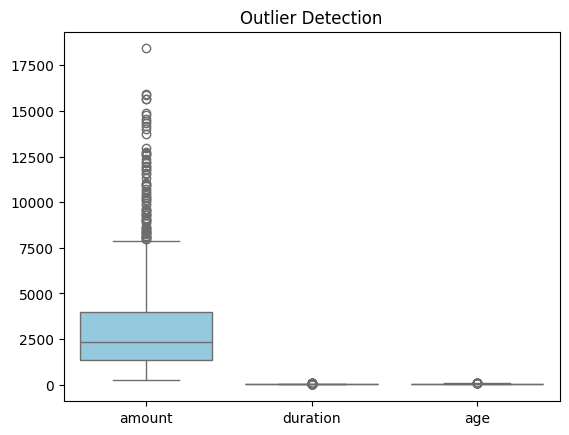

In [15]:
sns.boxplot(data=df[['amount','duration','age']],palette=['skyblue','salmon','lightgreen'])
plt.title('Outlier Detection')
plt.show()

### X,Y Seperation

In [16]:
# X,Y seperation
x=df.drop('credit_risk',axis=1)
y=df['credit_risk']

In [17]:
x

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker
0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2
1,1,9,4,0,2799,1,3,2,3,1,2,1,36,3,1,2,3,1,1,2
2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2
3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,4,2,38,1,2,2,2,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,4,1,21,3,1,1,2,1,1,2
996,1,24,2,0,2303,1,5,4,3,2,1,1,45,3,2,1,3,2,1,2
997,4,21,4,0,12680,5,5,4,3,1,4,4,30,3,3,1,4,2,2,2
998,2,12,2,3,6468,5,1,2,3,1,1,4,52,3,2,1,4,2,2,2


In [18]:
y

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: credit_risk, Length: 1000, dtype: int64

### Train test split

In [19]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [20]:
scaler=RobustScaler()
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.transform(xtest)

### Logistic Regression

In [21]:
model1=LogisticRegression(max_iter=1000)
model1.fit(xtrain_scaled,ytrain)

LogisticRegression(max_iter=1000)

In [22]:
y_pred1=model1.predict(xtest_scaled)
y_pred1

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1])

In [569]:
train_pred1=model1.predict(xtrain_scaled)

In [570]:
train_score1=accuracy_score(ytrain,train_pred1)
train_score1

0.7325

In [23]:
score1=accuracy_score(ytest,y_pred1)
score1

0.77

In [24]:
cm1=confusion_matrix(ytest,y_pred1)
cm1

array([[ 29,  31],
       [ 15, 125]])

In [25]:
cr1=classification_report(ytest,y_pred1)
print(cr1)

              precision    recall  f1-score   support

           0       0.66      0.48      0.56        60
           1       0.80      0.89      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200



###  Gaussian Naive Bayes

In [26]:
model2=GaussianNB()
model2.fit(xtrain_scaled,ytrain)

GaussianNB()

In [27]:
y_pred2=model1.predict(xtest_scaled)
y_pred2

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1])

In [572]:
train_pred2=model2.predict(xtrain_scaled)

In [574]:
train_score2=accuracy_score(ytrain,train_pred2)
train_score2

0.655

In [28]:
score2=accuracy_score(ytest,y_pred2)
score2

0.77

In [29]:
cm2=confusion_matrix(ytest,y_pred2)
cm2

array([[ 29,  31],
       [ 15, 125]])

In [30]:
cr2=classification_report(ytest,y_pred2)
print(cr2)

              precision    recall  f1-score   support

           0       0.66      0.48      0.56        60
           1       0.80      0.89      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200



### 
Decision Tree

In [31]:
model3=DecisionTreeClassifier(max_depth=5,random_state=42)
model3.fit(xtrain_scaled,ytrain)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [32]:
y_pred3=model3.predict(xtest_scaled)
y_pred3

array([0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1])

In [575]:
train_pred3=model3.predict(xtrain_scaled)

In [576]:
train_score3=accuracy_score(ytrain,train_pred3)
train_score3

0.75

In [33]:
score3=accuracy_score(ytest,y_pred3)
score3

0.69

In [34]:
cm3=confusion_matrix(ytest,y_pred3)
cm3

array([[40, 20],
       [42, 98]])

In [35]:
cr3=classification_report(ytest,y_pred3)
print(cr3)

              precision    recall  f1-score   support

           0       0.49      0.67      0.56        60
           1       0.83      0.70      0.76       140

    accuracy                           0.69       200
   macro avg       0.66      0.68      0.66       200
weighted avg       0.73      0.69      0.70       200



### Random Forest Classifier

In [36]:
model4=RandomForestClassifier(n_estimators=100,random_state=42)
model4.fit(xtrain_scaled,ytrain)

RandomForestClassifier(random_state=42)

In [37]:
y_pred4=model4.predict(xtest_scaled)
y_pred4

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1])

In [577]:
train_pred4=model4.predict(xtrain_scaled)

In [578]:
train_score4=accuracy_score(ytrain,train_pred4)
train_score4

1.0

In [38]:
score4=accuracy_score(ytest,y_pred4)
score4

0.8

In [39]:
cm4=confusion_matrix(ytest,y_pred4)
cm4

array([[ 30,  30],
       [ 10, 130]])

In [40]:
cr4=classification_report(ytest,y_pred4)
print(cr4)

              precision    recall  f1-score   support

           0       0.75      0.50      0.60        60
           1       0.81      0.93      0.87       140

    accuracy                           0.80       200
   macro avg       0.78      0.71      0.73       200
weighted avg       0.79      0.80      0.79       200



### AdaBoost Classifier

In [41]:
model5=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                          n_estimators=100,
                          learning_rate=1.0,
                          random_state=42)
model5.fit(xtrain_scaled,ytrain)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [42]:
y_pred5=model5.predict(xtest_scaled)
y_pred5

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1])

In [579]:
train_pred5=model5.predict(xtrain_scaled)

In [580]:
train_score5=accuracy_score(ytrain,train_pred5)
train_score5

0.76375

In [43]:
score5=accuracy_score(ytest,y_pred5)
score5

0.785

In [44]:
cm5=confusion_matrix(ytest,y_pred5)
cm5

array([[ 35,  25],
       [ 18, 122]])

In [45]:
cr5=classification_report(ytest,y_pred5)
print(cr5)

              precision    recall  f1-score   support

           0       0.66      0.58      0.62        60
           1       0.83      0.87      0.85       140

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.78      0.79      0.78       200



### Gradient Boosting

In [46]:
model6=GradientBoostingClassifier(n_estimators=100,
                                  learning_rate=0.1,
                                  max_depth=3,
                                  random_state=42)
model6.fit(xtrain_scaled,ytrain)

GradientBoostingClassifier(random_state=42)

In [47]:
y_pred6=model6.predict(xtest_scaled)
y_pred6

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [581]:
train_pred6=model6.predict(xtrain_scaled)

In [582]:
train_score6=accuracy_score(ytrain,train_pred6)
train_score6

0.88625

In [48]:
score6=accuracy_score(ytest,y_pred6)
score6

0.79

In [49]:
cm6=confusion_matrix(ytest,y_pred6)
cm6

array([[ 34,  26],
       [ 16, 124]])

In [50]:
cr6=classification_report(ytest,y_pred6)
print(cr6)

              precision    recall  f1-score   support

           0       0.68      0.57      0.62        60
           1       0.83      0.89      0.86       140

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.74       200
weighted avg       0.78      0.79      0.78       200



### XG Boost

In [583]:
model7=XGBClassifier(objective='binary:logistic',
                     learining_rate=0.1,
                     max_depth=3,
                     n_estimators=100,
                     random_state=42)
model7.fit(xtrain_scaled,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learining_rate=0.1, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [52]:
y_pred7=model7.predict(xtest_scaled)
y_pred7

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [584]:
train_pred7=model7.predict(xtrain_scaled)

In [585]:
train_score7=accuracy_score(ytrain,train_pred7)
train_score7

0.96625

In [53]:
score7=accuracy_score(ytest,y_pred7)
score7

0.8

In [54]:
cm7=confusion_matrix(ytest,y_pred7)
cm7

array([[ 34,  26],
       [ 14, 126]])

In [55]:
cr7=classification_report(ytest,y_pred7)
print(cr7)

              precision    recall  f1-score   support

           0       0.71      0.57      0.63        60
           1       0.83      0.90      0.86       140

    accuracy                           0.80       200
   macro avg       0.77      0.73      0.75       200
weighted avg       0.79      0.80      0.79       200



### SVC

In [56]:
model8=SVC(kernel='linear',C=1,random_state=42)
model8.fit(xtrain_scaled,ytrain)

SVC(C=1, kernel='linear', random_state=42)

In [57]:
y_pred8=model8.predict(xtest_scaled)
y_pred8

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1])

In [586]:
train_pred8=model8.predict(xtrain_scaled)

In [587]:
train_score8=accuracy_score(ytrain,train_pred8)
train_score8

0.7275

In [58]:
score8=accuracy_score(ytest,y_pred8)
score8

0.78

In [59]:
cm8=confusion_matrix(ytest,y_pred8)
cm8

array([[ 31,  29],
       [ 15, 125]])

In [60]:
cr8=classification_report(ytest,y_pred8)
print(cr8)

              precision    recall  f1-score   support

           0       0.67      0.52      0.58        60
           1       0.81      0.89      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.72       200
weighted avg       0.77      0.78      0.77       200



### KNN

In [61]:
model9=KNeighborsClassifier(n_neighbors=5)
model9.fit(xtrain_scaled,ytrain)

KNeighborsClassifier()

In [62]:
y_pred9=model9.predict(xtest_scaled)
y_pred9

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1])

In [588]:
train_pred9=model9.predict(xtrain_scaled)

In [589]:
train_score9=accuracy_score(ytrain,train_pred9)
train_score9

0.77375

In [63]:
score9=accuracy_score(ytest,y_pred9)
score9

0.71

In [64]:
cm9=confusion_matrix(ytest,y_pred9)
cm9

array([[ 22,  38],
       [ 20, 120]])

In [65]:
cr9=classification_report(ytest,y_pred9)
print(cr9)

              precision    recall  f1-score   support

           0       0.52      0.37      0.43        60
           1       0.76      0.86      0.81       140

    accuracy                           0.71       200
   macro avg       0.64      0.61      0.62       200
weighted avg       0.69      0.71      0.69       200



In [591]:
model_names=['Logistic Regression','Gaussian NB','Decision Tree','Random Forest','AdaBoost','Gradient Boosting','XG Boost','SVM','KNN']
score=[score1,score2,score3,score4,score5,score6,score7,score8,score9]
train=[train_score1,train_score2,train_score3,train_score4,train_score5,train_score6,train_score7,train_score8,train_score9]
pd.DataFrame({'Models':model_names,'Train_accuracy':train,'Test_accuracy':score})

,Models,Train_accuracy,Test_accuracy
0,Logistic Regression,0.73250,0.770
1,Gaussian NB,0.65500,0.770
2,Decision Tree,0.75000,0.690
3,Random Forest,1.00000,0.800
4,AdaBoost,0.76375,0.785
5,Gradient Boosting,0.88625,0.790
6,XG Boost,0.96625,0.800
7,SVM,0.72750,0.780
8,KNN,0.77375,0.710


## After Balancing

In [67]:
smote=SMOTE(random_state=42)
xtrain_sm,ytrain_sm=smote.fit_resample(xtrain_scaled,ytrain)

### Logistic Regression

In [541]:
md1=model1.fit(xtrain_sm,ytrain_sm)
md1

LogisticRegression(max_iter=1000)

In [542]:
ypred_1=md1.predict(xtest_scaled)
ypred_1

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [546]:
lr_pred=md1.predict(xtrain_sm)
lr_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [547]:
lrtrain=accuracy_score(ytrain_sm,lr_train_pred)
lrtrain

0.7473214285714286

In [543]:
score_1=accuracy_score(ytest,ypred_1)
score_1

0.71

In [544]:
cmb1=confusion_matrix(ytest,ypred_1)
cmb1

array([[43, 17],
       [41, 99]])

In [545]:
crb1=classification_report(ytest,ypred_1)
print(crb1)

              precision    recall  f1-score   support

           0       0.51      0.72      0.60        60
           1       0.85      0.71      0.77       140

    accuracy                           0.71       200
   macro avg       0.68      0.71      0.69       200
weighted avg       0.75      0.71      0.72       200



### Naive Bayes

In [73]:
md2=model2.fit(xtrain_sm,ytrain_sm)
md2

GaussianNB()

In [74]:
ypred_2=md2.predict(xtest_scaled)
ypred_2

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1])

In [548]:
gnb_pred=md2.predict(xtrain_sm)
gnb_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [549]:
traingnb=accuracy_score(ytrain_sm,gnb_pred)
traingnb

0.7241071428571428

In [75]:
score_2=accuracy_score(ytest,ypred_2)
score_2

0.645

In [76]:
cmb2=confusion_matrix(ytest,ypred_2)
cmb2

array([[48, 12],
       [59, 81]])

In [77]:
crb2=classification_report(ytest,ypred_2)
print(crb2)

              precision    recall  f1-score   support

           0       0.45      0.80      0.57        60
           1       0.87      0.58      0.70       140

    accuracy                           0.65       200
   macro avg       0.66      0.69      0.64       200
weighted avg       0.74      0.65      0.66       200



### Decision Tree

In [78]:
md3=model3.fit(xtrain_sm,ytrain_sm)
md3

DecisionTreeClassifier(max_depth=5, random_state=42)

In [79]:
ypred_3=md3.predict(xtest_scaled)
ypred_3

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [550]:
ds_pred=md3.predict(xtrain_sm)
ds_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [551]:
trainds=accuracy_score(ytrain_sm,ds_pred)
trainds

0.8035714285714286

In [80]:
score_3=accuracy_score(ytest,ypred_3)
score_3

0.71

In [81]:
cmb3=confusion_matrix(ytest,ypred_3)
cmb3

array([[ 40,  20],
       [ 38, 102]])

In [82]:
crb3=classification_report(ytest,ypred_3)
print(crb3)

              precision    recall  f1-score   support

           0       0.51      0.67      0.58        60
           1       0.84      0.73      0.78       140

    accuracy                           0.71       200
   macro avg       0.67      0.70      0.68       200
weighted avg       0.74      0.71      0.72       200



### Random Forest

In [83]:
md4=model4.fit(xtrain_sm,ytrain_sm)
md4

RandomForestClassifier(random_state=42)

In [84]:
ypred_4=md4.predict(xtest_scaled)
ypred_4

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [552]:
rf_pred=md4.predict(xtrain_sm)
rf_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [553]:
trainrf=accuracy_score(ytrain_sm,rf_pred)
trainrf

1.0

In [85]:
score_4=accuracy_score(ytest,ypred_4)
score_4

0.785

In [86]:
cmb4=confusion_matrix(ytest,ypred_4)
cmb4

array([[ 35,  25],
       [ 18, 122]])

In [87]:
crb4=classification_report(ytest,ypred_4)
print(crb4)

              precision    recall  f1-score   support

           0       0.66      0.58      0.62        60
           1       0.83      0.87      0.85       140

    accuracy                           0.79       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.78      0.79      0.78       200



### Ada Boosting

In [88]:
md5=model5.fit(xtrain_sm,ytrain_sm)
md5

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [89]:
ypred_5=md5.predict(xtest_scaled)
ypred_5

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [554]:
ada_pred=md5.predict(xtrain_sm)
ada_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [555]:
trainada=accuracy_score(ytrain_sm,ada_pred)
trainada

0.8205357142857143

In [90]:
score_5=accuracy_score(ytest,ypred_5)
score_5

0.76

In [91]:
cmb5=confusion_matrix(ytest,ypred_5)
cmb5

array([[ 42,  18],
       [ 30, 110]])

In [92]:
crb5=classification_report(ytest,ypred_5)
print(crb5)

              precision    recall  f1-score   support

           0       0.58      0.70      0.64        60
           1       0.86      0.79      0.82       140

    accuracy                           0.76       200
   macro avg       0.72      0.74      0.73       200
weighted avg       0.78      0.76      0.77       200



### Gradient Boosting

In [93]:
md6=model6.fit(xtrain_sm,ytrain_sm)
md6

GradientBoostingClassifier(random_state=42)

In [94]:
ypred_6=md6.predict(xtest_scaled)
ypred_6

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [556]:
gb_pred=md6.predict(xtrain_sm)
gb_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [557]:
traingb=accuracy_score(ytrain_sm,gb_pred)
traingb

0.91875

In [95]:
score_6=accuracy_score(ytest,ypred_6)
score_6

0.745

In [96]:
cmb6=confusion_matrix(ytest,ypred_6)
cmb6

array([[ 34,  26],
       [ 25, 115]])

In [97]:
crb6=classification_report(ytest,ypred_6)
print(crb6)

              precision    recall  f1-score   support

           0       0.58      0.57      0.57        60
           1       0.82      0.82      0.82       140

    accuracy                           0.74       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.74      0.74      0.74       200



### XG Boost

In [558]:
md7=model7.fit(xtrain_sm,ytrain_sm)
md7

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learining_rate=0.1, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [559]:
xgb_pred=md7.predict(xtrain_sm)
xgb_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [99]:
ypred_7=md7.predict(xtest_scaled)
ypred_7

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1])

In [560]:
trainxgb=accuracy_score(ytrain_sm,xgb_pred)
trainxgb

0.9723214285714286

In [100]:
score_7=accuracy_score(ytest,ypred_7)
score_7

0.77

In [101]:
cmb7=confusion_matrix(ytest,ypred_7)
cmb7

array([[ 37,  23],
       [ 23, 117]])

In [102]:
crb7=classification_report(ytest,ypred_7)
print(crb7)

              precision    recall  f1-score   support

           0       0.62      0.62      0.62        60
           1       0.84      0.84      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.77      0.77      0.77       200



### SVM

In [103]:
md8=model8.fit(xtrain_sm,ytrain_sm)
md8

SVC(C=1, kernel='linear', random_state=42)

In [104]:
ypred_8=md8.predict(xtest_scaled)
ypred_8

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [561]:
svm_pred=md8.predict(xtrain_sm)
svm_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(1120,))

In [562]:
trainsvm=accuracy_score(ytrain_sm,svm_pred)
trainsvm

0.7446428571428572

In [105]:
score_8=accuracy_score(ytest,ypred_8)
score_8

0.72

In [106]:
cmb8=confusion_matrix(ytest,ypred_8)
cmb8

array([[45, 15],
       [41, 99]])

In [107]:
crb8=classification_report(ytest,ypred_8)
print(crb8)

              precision    recall  f1-score   support

           0       0.52      0.75      0.62        60
           1       0.87      0.71      0.78       140

    accuracy                           0.72       200
   macro avg       0.70      0.73      0.70       200
weighted avg       0.76      0.72      0.73       200



### KNN

In [108]:
md9=model9.fit(xtrain_sm,ytrain_sm)
md9

KNeighborsClassifier()

In [109]:
ypred_9=md9.predict(xtest_scaled)
ypred_9

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1])

In [563]:
knn_pred=md9.predict(xtrain_sm)
knn_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [564]:
trainknn=accuracy_score(ytrain_sm,knn_pred)
trainknn

0.8357142857142857

In [565]:
score_9=accuracy_score(ytest,ypred_9)
score_9

0.6

In [111]:
cmb9=confusion_matrix(ytest,ypred_9)
cmb9

array([[42, 18],
       [62, 78]])

In [112]:
crb9=classification_report(ytest,ypred_9)
print(crb9)

              precision    recall  f1-score   support

           0       0.40      0.70      0.51        60
           1       0.81      0.56      0.66       140

    accuracy                           0.60       200
   macro avg       0.61      0.63      0.59       200
weighted avg       0.69      0.60      0.62       200



In [566]:
scores=[score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9]
train_score=[lrtrain,traingnb,trainds,trainrf,trainada,traingb,trainxgb,trainsvm,trainknn]
pd.DataFrame({'Models':model_names,'Accuracy before balancing':score,'Accuracy after balancing':scores})

,Models,Accuracy before balancing,Accuracy after balancing
0,Logistic Regression,0.770,0.710
1,Gaussian NB,0.770,0.645
2,Decision Tree,0.690,0.710
3,Random Forest,0.800,0.785
4,AdaBoost,0.785,0.760
5,Gradient Boosting,0.790,0.745
6,XG Boost,0.800,0.770
7,SVM,0.780,0.720
8,KNN,0.710,0.600


In [567]:
pd.DataFrame({'Models':model_names,'Train_accuracy_after_balancing':train_score,'Test_accuracy_after_balancing':scores})

,Models,Train_accuracy_after_balancing,Test_accuracy_after_balancing
0,Logistic Regression,0.747321,0.710
1,Gaussian NB,0.724107,0.645
2,Decision Tree,0.803571,0.710
3,Random Forest,1.000000,0.785
4,AdaBoost,0.820536,0.760
5,Gradient Boosting,0.918750,0.745
6,XG Boost,0.972321,0.770
7,SVM,0.744643,0.720
8,KNN,0.835714,0.600


## Hyper Parameter Tuning

### Logistic regression

In [114]:
lr=GridSearchCV(md1,{'C':[1,5,10],'penalty':['l1','l2'],'solver':['liblinear','saga']},cv=5,return_train_score=True)
lr.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [1, 5, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             return_train_score=True)

In [115]:
lr1=lr.cv_results_

In [116]:
lr.best_params_

{'C': 5, 'penalty': 'l1', 'solver': 'liblinear'}

In [117]:
s1=lr.best_score_
s1

np.float64(0.7303571428571429)

In [118]:
lr_model=LogisticRegression(C=5,penalty='l1',solver='liblinear')
lr_model.fit(xtrain_sm,ytrain_sm)

LogisticRegression(C=5, penalty='l1', solver='liblinear')

In [119]:
lr_train_pred=lr_model.predict(xtrain_sm)
lr_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [120]:
lr_test_pred=lr_model.predict(xtest_scaled)
lr_test_pred

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [121]:
train_score_lr=accuracy_score(ytrain_sm,lr_train_pred)
train_score_lr

0.7473214285714286

In [122]:
test_score_lr=accuracy_score(ytest,lr_test_pred)
test_score_lr

0.715

### Naive Bayes

In [123]:
param_grid={'var_smoothing':[1e-9,1e-8,1e-7,1e-6,1e-5]}
GN=GridSearchCV(md2,param_grid,cv=5,return_train_score=True)
GN.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05]},
             return_train_score=True)

In [124]:
GN1=GN.cv_results_

In [125]:
GN.best_params_

{'var_smoothing': 1e-09}

In [126]:
s2=GN.best_score_
s2

np.float64(0.7107142857142856)

In [127]:
gnb_model=GaussianNB(var_smoothing=1e-9)
gnb_model.fit(xtrain_sm,ytrain_sm)

GaussianNB()

In [128]:
gnb_train_pred=gnb_model.predict(xtrain_sm)
gnb_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [129]:
gnb_test_pred=gnb_model.predict(xtest_scaled)
gnb_test_pred

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1])

In [130]:
train_score_gnb=accuracy_score(ytrain_sm,gnb_train_pred)
train_score_gnb

0.7241071428571428

In [131]:
test_score_gnb=accuracy_score(ytest,gnb_test_pred)
test_score_gnb

0.645

### Decision Tree 

In [259]:
ds=GridSearchCV(md3,{'criterion':['gini','entropy'],
                    'max_depth':[6,7,8],
                    'min_samples_split':[5,10,15],
                    'min_samples_leaf':[3,5,7]},
                    cv=5,return_train_score=True)
ds.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [6, 7, 8], 'min_samples_leaf': [3, 5, 7],
                         'min_samples_split': [5, 10, 15]},
             return_train_score=True)

In [260]:
ds1=ds.cv_results_

In [261]:
ds.best_params_

{'criterion': 'gini',
 'max_depth': 7,
 'min_samples_leaf': 7,
 'min_samples_split': 15}

In [262]:
s3=ds.best_score_

In [263]:
ds_model=DecisionTreeClassifier(criterion='gini',max_depth=7,min_samples_leaf=7,min_samples_split=15)
ds_model.fit(xtrain_sm,ytrain_sm)

DecisionTreeClassifier(max_depth=7, min_samples_leaf=7, min_samples_split=15)

In [264]:
ds_train_pred=ds_model.predict(xtrain_sm)
ds_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [265]:
ds_test_pred=ds_model.predict(xtest_scaled)
ds_test_pred

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1])

In [266]:
train_score_ds=accuracy_score(ytrain_sm,ds_train_pred)
train_score_ds

0.8526785714285714

In [267]:
test_score_ds=accuracy_score(ytest,ds_test_pred)
test_score_ds

0.725

### Random Forest 

In [278]:
rf=GridSearchCV(md4,{'n_estimators':[100,200],
                     'max_depth':[6,7,8],
                     'min_samples_split':[10,15,20],
                     'min_samples_leaf':[3,5,7],
                    'max_features':['sqrt'],
                    'criterion':['gini','entropy']},
                     cv=5,return_train_score=True)
rf.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [6, 7, 8], 'max_features': ['sqrt'],
                         'min_samples_leaf': [3, 5, 7],
                         'min_samples_split': [10, 15, 20],
                         'n_estimators': [100, 200]},
             return_train_score=True)

In [279]:
rf1=rf.cv_results_

In [280]:
rf.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 100}

In [272]:
s4=rf.best_score_

In [281]:
rf_model=RandomForestClassifier(criterion='gini',max_depth=8,max_features='sqrt',min_samples_leaf=3,min_samples_split=10,n_estimators=100)
rf_model.fit(xtrain_sm,ytrain_sm)

RandomForestClassifier(max_depth=8, min_samples_leaf=3, min_samples_split=10)

In [282]:
rf_train_pred=rf_model.predict(xtrain_sm)
rf_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [283]:
rf_test_pred=rf_model.predict(xtest_scaled)
rf_test_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1])

In [284]:
train_score_rf=accuracy_score(ytrain_sm,rf_train_pred)
train_score_rf

0.9116071428571428

In [285]:
test_score_rf=accuracy_score(ytest,rf_test_pred)
test_score_rf

0.785

### Ada Boosting

In [286]:
ada=GridSearchCV(md5,{'n_estimators':[100,150,200],
                      'learning_rate':[0.01,0.1,0.2,0.3]},
                      cv=5,return_train_score=True)
ada.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                          n_estimators=100, random_state=42),
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'n_estimators': [100, 150, 200]},
             return_train_score=True)

In [287]:
ada1=ada.cv_results_

In [288]:
ada.best_params_

{'learning_rate': 0.3, 'n_estimators': 200}

In [289]:
s5=ada.best_score_
s5

np.float64(0.7794642857142857)

In [290]:
ada_model=AdaBoostClassifier(learning_rate=0.3,n_estimators=200)
ada_model.fit(xtrain_sm,ytrain_sm)

AdaBoostClassifier(learning_rate=0.3, n_estimators=200)

In [291]:
ada_train_pred=ada_model.predict(xtrain_sm)
ada_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [292]:
ada_test_pred=ada_model.predict(xtest_scaled)
ada_test_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [293]:
train_score_ada=accuracy_score(ytrain_sm,ada_train_pred)
train_score_ada

0.8026785714285715

In [294]:
test_score_ada=accuracy_score(ytest,ada_test_pred)
test_score_ada

0.77

### Gradient Boosting

In [395]:
gb=GridSearchCV(md6,{'n_estimators':[100,200],
                     'learning_rate':[0.01,0.1],
                     'max_depth':[3,5],
                    },cv=5,return_train_score=True)
gb.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             return_train_score=True)

In [396]:
gb1=gb.cv_results_

In [397]:
gb.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

In [398]:
s6=gb.best_score_
s6

np.float64(0.8205357142857143)

In [399]:
gb_model=GradientBoostingClassifier(learning_rate=0.1,max_depth=3,n_estimators=100)
gb_model.fit(xtrain_sm,ytrain_sm)

GradientBoostingClassifier()

In [400]:
gb_train_pred=gb_model.predict(xtrain_sm)
gb_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [401]:
gb_test_pred=gb_model.predict(xtest_scaled)
gb_test_pred

array([0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 1])

In [402]:
train_score_gb=accuracy_score(ytrain_sm,gb_train_pred)
train_score_gb

0.91875

In [403]:
test_score_gb=accuracy_score(ytest,gb_test_pred)
test_score_gb

0.745

### XG Boost

In [346]:
xg=GridSearchCV(md7,{'n-estimators':[150,200],
                     'learning_rate':[0.01,0.05,0.1],
                     'max_depth':[3,4],
                     'subsample':[0.8,1],
                     'colsample_bytree':[0.8,1],
                     'reg_lambda':[1,1.5],
                     'reg_alpha':[0,0.5]},cv=5,return_train_score=True)
xg.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=3,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, ...),
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4], 'n-estimators': [150, 200],
                         'reg_alpha': [0, 0.5], 'reg_lambda': [1, 1.5],
                         'subsample': [0.8, 1]},
             return_train_score=True)

In [347]:
xg1=xg.cv_results_

In [348]:
xg.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 4,
 'n-estimators': 150,
 'reg_alpha': 0,
 'reg_lambda': 1,
 'subsample': 0.8}

In [349]:
s7=xg.best_score_
s7

np.float64(0.8151785714285715)

In [355]:
xg_model=XGBClassifier(objective='binary:logistic',colsample_bytree=1,learning_rate=0.1,max_depth=4,n_estimators=150,
                       subsample=0.8,reg_alpha=0,reg_lambda=1,random_state=42)
xg_model.fit(xtrain_sm,ytrain_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [356]:
xg_train_pred=xg_model.predict(xtrain_sm)
xg_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [357]:
xg_test_pred=xg_model.predict(xtest_scaled)
xg_test_pred

array([1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1])

In [358]:
train_score_xg=accuracy_score(ytrain_sm,xg_train_pred)
train_score_xg

0.9741071428571428

In [359]:
test_score_xg=accuracy_score(ytest,xg_test_pred)
test_score_xg

0.795

### SVM

In [461]:
sv=GridSearchCV(md8,{'C':[0.1,1],
                     'kernel':['linear','rbf'],
                     'gamma':['scale','auto']},
                    
                cv=5,return_train_score=True)
sv.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5, estimator=SVC(C=1, kernel='linear', random_state=42),
             param_grid={'C': [0.1, 1], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             return_train_score=True)

In [462]:
sv1=sv.cv_results_

In [463]:
sv.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [456]:
s8=sv.best_score_
s8

np.float64(0.7901785714285714)

In [464]:
sv_model=SVC(C=1,gamma='scale',kernel='rbf')
sv_model.fit(xtrain_sm,ytrain_sm)

SVC(C=1)

In [465]:
sv_train_pred=sv_model.predict(xtrain_sm)
sv_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [466]:
sv_test_pred=sv_model.predict(xtest_scaled)
sv_test_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1])

In [467]:
train_score_sv=accuracy_score(ytrain_sm,sv_train_pred)
train_score_sv

0.8785714285714286

In [468]:
test_score_sv=accuracy_score(ytest,sv_test_pred)
test_score_sv

0.775

### KNN

In [529]:
knn=GridSearchCV(md9,{'n_neighbors':[5,7,9],
                      'metric':['euclidean','manhattan']},
                 cv=5,return_train_score=True)
knn.fit(xtrain_sm,ytrain_sm)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [5, 7, 9]},
             return_train_score=True)

In [530]:
kn1=knn.cv_results_

In [531]:
knn.best_params_

{'metric': 'manhattan', 'n_neighbors': 5}

In [532]:
s9=knn.best_score_
s9

np.float64(0.7982142857142858)

In [533]:
knn_model=KNeighborsClassifier(n_neighbors=5,metric='manhattan')
knn_model.fit(xtrain_sm,ytrain_sm)

KNeighborsClassifier(metric='manhattan')

In [534]:
knn_train_pred=knn_model.predict(xtrain_sm)
knn_train_pred

array([1, 1, 1, ..., 0, 0, 0], shape=(1120,))

In [535]:
knn_test_pred=knn_model.predict(xtest_scaled)
knn_test_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1])

In [536]:
train_score_knn=accuracy_score(ytrain_sm,knn_train_pred)
train_score_knn

0.8830357142857143

In [537]:
test_score_knn=accuracy_score(ytest,knn_test_pred)
test_score_knn

0.66

In [538]:
tuning_score=[s1,s2,s3,s4,s5,s6,s7,s8,s9]
train_tuning_score=[train_score_lr,train_score_gnb,train_score_ds,train_score_rf,train_score_ada,train_score_gb,
                    train_score_xg,train_score_sv,train_score_knn]
test_tuning_score=[test_score_lr,test_score_gnb,test_score_ds,test_score_rf,test_score_ada,test_score_gb,
                   test_score_xg,test_score_sv,test_score_knn]

In [539]:
pd.DataFrame({'Models':model_names,'Accuracy':scores,'Accuracy_after_hyperparameter_tuning':test_tuning_score})

,Models,Accuracy,Accuracy_after_hyperparameter_tuning
0,Logistic Regression,0.710,0.715
1,Gaussian NB,0.645,0.645
2,Decision Tree,0.710,0.725
3,Random Forest,0.785,0.785
4,AdaBoost,0.760,0.770
5,Gradient Boosting,0.745,0.745
6,XG Boost,0.770,0.795
7,SVM,0.720,0.775
8,KNN,0.600,0.660


In [540]:
pd.DataFrame({'Models':model_names,'train_accuracy':train_tuning_score,'test_accuracy':test_tuning_score})

,Models,train_accuracy,test_accuracy
0,Logistic Regression,0.747321,0.715
1,Gaussian NB,0.724107,0.645
2,Decision Tree,0.852679,0.725
3,Random Forest,0.911607,0.785
4,AdaBoost,0.802679,0.770
5,Gradient Boosting,0.918750,0.745
6,XG Boost,0.974107,0.795
7,SVM,0.878571,0.775
8,KNN,0.883036,0.660
